# Cold 4-bet strategy analysis

This notebook builds two pre-flop regression models from your 168-scenario dataset:

1. **4-bet range model** using `FOURBET_RANGE_LOGIT`, and
2. **4-bet sizing model** using `FOURBET_SIZE_RELATIVE`.

The workflow covers:

- data loading from `notebooks/4-bet data.csv` (repo root) or `4-bet data.csv` (when cwd is `notebooks/`),
- feature engineering,
- exploratory distributions,
- null models and baseline frequency on the logit scale,
- forward **BIC** variable selection on **numeric** predictors only (no position/game factors),
- fitted-model summaries and coefficient importance (by |t|),
- per-observation and heatmap diagnostics, and
- grouped actual-versus-expected plots by game and positions.

> **Expected input columns**
>
> `RECORD_NO`, `GAME`, `OPEN`, `OPEN_SIZE_ABS`, `3BET`, `3BET_SIZE_ABS`, `4BET`, `4BET_RANGE`, `4BET_SIZE_ABS`


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import display

warnings.filterwarnings("ignore", category=RuntimeWarning)

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


In [2]:
# --- Configuration ---------------------------------------------------------
# Fixed locations only (no searching): repo root uses notebooks/4-bet data.csv;
# if the notebook's cwd is notebooks/, use 4-bet data.csv in that folder.
if (Path("notebooks") / "4-bet data.csv").is_file():
    DATA_PATH = Path("notebooks") / "4-bet data.csv"
else:
    DATA_PATH = Path("4-bet data.csv")

GAME_ORDER = ["CASH 100bb", "MTT ChipEV 80bb", "MTT ICM (50% left) 35bb"]
OPEN_ORDER = ["UTG", "UTG+1", "LJ", "HJ", "CO", "BTN"]
THREEBET_ORDER = ["UTG+1", "LJ", "HJ", "CO", "BTN", "SB"]
FOURBET_ORDER = ["LJ", "HJ", "CO", "BTN", "SB", "BB"]
TABLE_ORDER = ["UTG", "UTG+1", "LJ", "HJ", "CO", "BTN", "SB", "BB"]
POSITION_TO_INDEX = {position: index for index, position in enumerate(TABLE_ORDER)}

EXPECTED_COLUMNS = {
    "RECORD_NO",
    "GAME",
    "OPEN",
    "OPEN_SIZE_ABS",
    "3BET",
    "3BET_SIZE_ABS",
    "4BET",
    "4BET_RANGE",
    "4BET_SIZE_ABS",
}


In [3]:
def load_fourbet_data(data_path: str | Path) -> pd.DataFrame:
    """Load the 4-bet dataset, standardise the main column names, and validate schema."""
    path = Path(data_path)
    if not path.is_file():
        raise FileNotFoundError(f"Dataset not found: {path.resolve()}")

    if path.suffix.lower() == ".csv":
        raw = pd.read_csv(path)
    elif path.suffix.lower() in {".xlsx", ".xls"}:
        raw = pd.read_excel(path)
    else:
        raise ValueError(f"Unsupported file type: {path.suffix}")

    missing_raw = EXPECTED_COLUMNS.difference(raw.columns)
    if missing_raw:
        raise ValueError(f"Dataset is missing required columns: {sorted(missing_raw)}")

    df = raw.rename(
        columns={
            "3BET": "THREEBET_POS",
            "4BET": "FOURBET_POS",
            "OPEN": "OPEN_POS",
            "3BET_SIZE_ABS": "THREEBET_SIZE_ABS",
            "4BET_RANGE": "FOURBET_RANGE",
        }
    ).copy()

    reverse_lookup = {
        "OPEN_POS": "OPEN",
        "THREEBET_POS": "3BET",
        "FOURBET_POS": "4BET",
    }
    df = df.rename(columns={alias: canonical for alias, canonical in reverse_lookup.items() if alias in df.columns})
    # First rename used THREEBET_SIZE_ABS; downstream prepare_features expects 3BET_SIZE_ABS.
    if "THREEBET_SIZE_ABS" in df.columns:
        df = df.rename(columns={"THREEBET_SIZE_ABS": "3BET_SIZE_ABS"})

    df = df.sort_values("RECORD_NO").reset_index(drop=True)
    return df


In [4]:
def circular_distance(start: str, end: str, order: list[str]) -> int:
    """Measure clockwise distance between two table positions on an 8-max table."""
    start_idx = POSITION_TO_INDEX[start]
    end_idx = POSITION_TO_INDEX[end]
    return (end_idx - start_idx) % len(order)


def prepare_features(df: pd.DataFrame) -> pd.DataFrame:
    """Engineer modelling and visualisation features for the cold 4-bet analysis."""
    data = df.copy()

    # Preserve original names, then create modelling-friendly aliases.
    data = data.rename(columns={"OPEN": "OPEN_POS", "3BET": "THREEBET_POS", "4BET": "FOURBET_POS"})

    # Ordered categorical variables for plotting and modelling.
    data["V_GAME"] = pd.Categorical(data["GAME"], categories=GAME_ORDER, ordered=True)
    data["V_OPEN"] = pd.Categorical(data["OPEN_POS"], categories=OPEN_ORDER, ordered=True)
    data["V_3BET"] = pd.Categorical(data["THREEBET_POS"], categories=THREEBET_ORDER, ordered=True)
    data["V_4BET"] = pd.Categorical(data["FOURBET_POS"], categories=FOURBET_ORDER, ordered=True)

    # Explicit one-hot encodings (columns open_<POS>, threebet_<POS>, fourbet_<POS>; same info as open_utg_ind-style indicators).
    data = pd.get_dummies(
        data,
        columns=["OPEN_POS", "THREEBET_POS", "FOURBET_POS"],
        prefix=["open", "threebet", "fourbet"],
        dtype=int,
    )

    # Restore readable categorical fields after get_dummies for formula-based modelling.
    data["OPEN_POS"] = data[[f"open_{p}" for p in OPEN_ORDER]].idxmax(axis=1).str.replace("open_", "", regex=False)
    data["THREEBET_POS"] = data[[f"threebet_{p}" for p in THREEBET_ORDER]].idxmax(axis=1).str.replace("threebet_", "", regex=False)
    data["FOURBET_POS"] = data[[f"fourbet_{p}" for p in FOURBET_ORDER]].idxmax(axis=1).str.replace("fourbet_", "", regex=False)

    # Ordered categorical dtype for the restored fields.
    data["OPEN_POS"] = pd.Categorical(data["OPEN_POS"], categories=OPEN_ORDER, ordered=True)
    data["THREEBET_POS"] = pd.Categorical(data["THREEBET_POS"], categories=THREEBET_ORDER, ordered=True)
    data["FOURBET_POS"] = pd.Categorical(data["FOURBET_POS"], categories=FOURBET_ORDER, ordered=True)

    # Response variables. Clip range away from 0 and 1 so the logit is finite.
    eps = 1e-6
    clipped_range = data["FOURBET_RANGE"].clip(eps, 1 - eps)
    data["FOURBET_RANGE_LOGIT"] = np.log(clipped_range / (1 - clipped_range))
    data["FOURBET_SIZE_RELATIVE"] = data["4BET_SIZE_ABS"] / data["3BET_SIZE_ABS"]

    # Size features (do not use 4BET_SIZE_ABS or transforms of it as predictors; FOURBET_SIZE_RELATIVE is the sizing response only).
    data["THREEBET_OVER_OPEN"] = data["3BET_SIZE_ABS"] / data["OPEN_SIZE_ABS"]

    # Early = strongest positions; late = CO/BTN. LJ/HJ are neither (baseline with intercept).
    data["OPEN_IS_EARLY"] = data["OPEN_POS"].isin(["UTG", "UTG+1"]).astype(int)
    data["OPEN_IS_LATE"] = data["OPEN_POS"].isin(["CO", "BTN"]).astype(int)
    data["THREEBETTER_IN_BLINDS"] = data["THREEBET_POS"].isin(["SB", "BB"]).astype(int)
    data["FOURBETTER_IN_BLINDS"] = data["FOURBET_POS"].isin(["SB", "BB"]).astype(int)
    data["FOURBETTER_IS_BB"] = (data["FOURBET_POS"] == "BB").astype(int)
    data["FOURBETTER_IS_SB"] = (data["FOURBET_POS"] == "SB").astype(int)
    data["BTN_INVOLVED"] = (
        (data["OPEN_POS"] == "BTN") | (data["THREEBET_POS"] == "BTN") | (data["FOURBET_POS"] == "BTN")
    ).astype(int)

    # Positional spacing features using table order.
    data["OPEN_TO_THREEBET_DISTANCE"] = [
        circular_distance(open_pos, threebet_pos, TABLE_ORDER)
        for open_pos, threebet_pos in zip(data["OPEN_POS"], data["THREEBET_POS"])
    ]
    data["THREEBET_TO_FOURBET_DISTANCE"] = [
        circular_distance(threebet_pos, fourbet_pos, TABLE_ORDER)
        for threebet_pos, fourbet_pos in zip(data["THREEBET_POS"], data["FOURBET_POS"])
    ]
    data["OPEN_TO_FOURBET_DISTANCE"] = [
        circular_distance(open_pos, fourbet_pos, TABLE_ORDER)
        for open_pos, fourbet_pos in zip(data["OPEN_POS"], data["FOURBET_POS"])
    ]

    # Matchup labels can be useful for grouped diagnostics.
    data["OPEN_THREEBET_MATCHUP"] = data["OPEN_POS"].astype(str) + " -> " + data["THREEBET_POS"].astype(str)
    data["THREEBET_FOURBET_MATCHUP"] = data["THREEBET_POS"].astype(str) + " -> " + data["FOURBET_POS"].astype(str)

    return data


In [5]:
raw_df = load_fourbet_data(DATA_PATH)
analysis_df = prepare_features(raw_df)

print(f"Loaded {len(analysis_df)} rows and {analysis_df.shape[1]} columns.")
display(analysis_df.head())


Loaded 168 rows and 46 columns.


,RECORD_NO,GAME,OPEN_SIZE_ABS,3BET_SIZE_ABS,FOURBET_RANGE,4BET_SIZE_ABS,V_GAME,V_OPEN,V_3BET,V_4BET,open_BTN,open_CO,open_HJ,open_LJ,open_UTG,open_UTG+1,threebet_BTN,threebet_CO,threebet_HJ,threebet_LJ,threebet_SB,threebet_UTG+1,fourbet_BB,fourbet_BTN,fourbet_CO,fourbet_HJ,fourbet_LJ,fourbet_SB,OPEN_POS,THREEBET_POS,FOURBET_POS,FOURBET_RANGE_LOGIT,FOURBET_SIZE_RELATIVE,THREEBET_OVER_OPEN,OPEN_IS_EARLY,OPEN_IS_LATE,THREEBETTER_IN_BLINDS,FOURBETTER_IN_BLINDS,FOURBETTER_IS_BB,FOURBETTER_IS_SB,BTN_INVOLVED,OPEN_TO_THREEBET_DISTANCE,THREEBET_TO_FOURBET_DISTANCE,OPEN_TO_FOURBET_DISTANCE,OPEN_THREEBET_MATCHUP,THREEBET_FOURBET_MATCHUP
0,1,CASH 100bb,2.0,6.5,0.029,14.0,CASH 100bb,UTG,UTG+1,LJ,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,UTG,UTG+1,LJ,-3.511031,2.153846,3.25,1,0,0,0,0,0,0,1,1,2,UTG -> UTG+1,UTG+1 -> LJ
1,2,CASH 100bb,2.0,6.5,0.029,14.0,CASH 100bb,UTG,UTG+1,HJ,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,UTG,UTG+1,HJ,-3.511031,2.153846,3.25,1,0,0,0,0,0,0,1,2,3,UTG -> UTG+1,UTG+1 -> HJ
2,3,CASH 100bb,2.0,6.5,0.028,14.0,CASH 100bb,UTG,UTG+1,CO,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,UTG,UTG+1,CO,-3.547151,2.153846,3.25,1,0,0,0,0,0,0,1,3,4,UTG -> UTG+1,UTG+1 -> CO
3,4,CASH 100bb,2.0,6.5,0.027,14.0,CASH 100bb,UTG,UTG+1,BTN,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,UTG,UTG+1,BTN,-3.584547,2.153846,3.25,1,0,0,0,0,0,1,1,4,5,UTG -> UTG+1,UTG+1 -> BTN
4,5,CASH 100bb,2.0,6.5,0.025,20.0,CASH 100bb,UTG,UTG+1,SB,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,UTG,UTG+1,SB,-3.663562,3.076923,3.25,1,0,0,1,0,1,0,1,5,6,UTG -> UTG+1,UTG+1 -> SB


In [6]:
summary_table = pd.DataFrame(
    {
        "mean": analysis_df[["FOURBET_RANGE", "FOURBET_RANGE_LOGIT", "FOURBET_SIZE_RELATIVE"]].mean(),
        "std": analysis_df[["FOURBET_RANGE", "FOURBET_RANGE_LOGIT", "FOURBET_SIZE_RELATIVE"]].std(),
        "min": analysis_df[["FOURBET_RANGE", "FOURBET_RANGE_LOGIT", "FOURBET_SIZE_RELATIVE"]].min(),
        "max": analysis_df[["FOURBET_RANGE", "FOURBET_RANGE_LOGIT", "FOURBET_SIZE_RELATIVE"]].max(),
    }
)
display(summary_table.round(4))


,mean,std,min,max
FOURBET_RANGE,0.0377,0.0109,0.0230,0.1030
FOURBET_RANGE_LOGIT,-3.2733,0.2621,-3.7490,-2.1643
FOURBET_SIZE_RELATIVE,2.2984,0.3502,1.9167,3.0769


## Exploratory distributions

Histograms (with KDE) for the raw 4-bet frequency and relative sizing before fitting models.


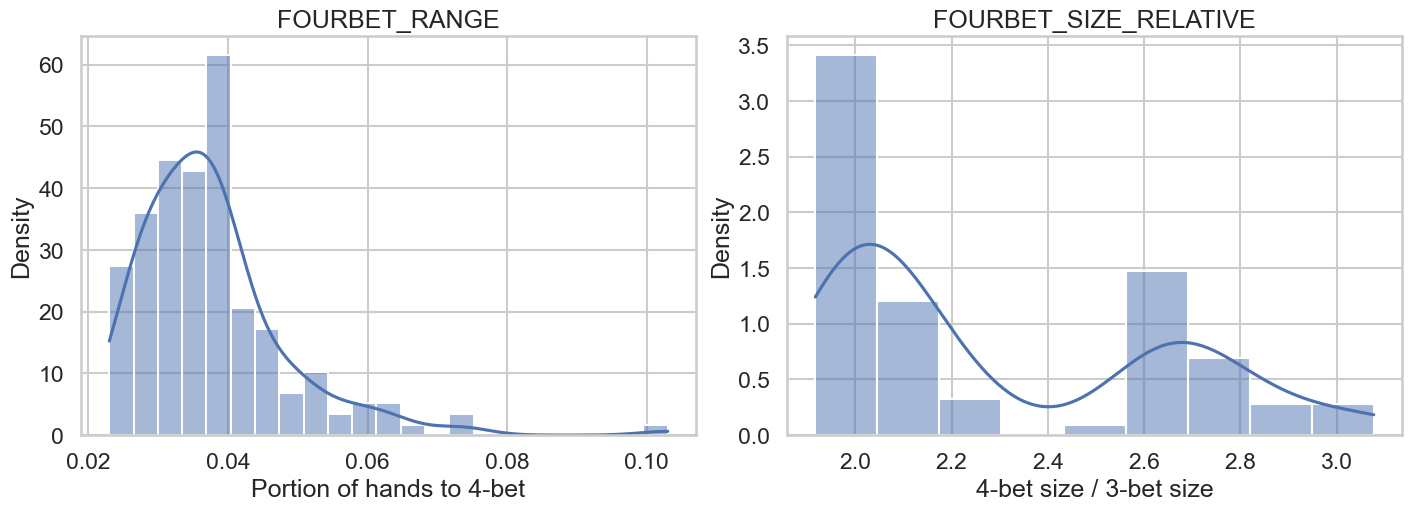

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
sns.histplot(analysis_df["FOURBET_RANGE"], kde=True, stat="density", ax=axes[0])
axes[0].set_title("FOURBET_RANGE")
axes[0].set_xlabel("Portion of hands to 4-bet")
sns.histplot(analysis_df["FOURBET_SIZE_RELATIVE"], kde=True, stat="density", ax=axes[1])
axes[1].set_title("FOURBET_SIZE_RELATIVE")
axes[1].set_xlabel("4-bet size / 3-bet size")
plt.show()


## Model specification

We estimate two OLS models:

- `FOURBET_RANGE_LOGIT ~ features`
- `FOURBET_SIZE_RELATIVE ~ features`

Each model starts from a null/intercept-only specification and then uses **greedy forward selection** that minimizes **BIC** at each step. **Only numeric predictors** enter selection (sizes, stack distances, blind/button flags). Categorical structure (game, positions) is still used for **V_*** plots and diagnostics but is not in the selection pool—BIC tends to prefer **smaller** models than AIC.

With **n = 168**, treat selected coefficients as descriptive summaries of this GTO grid, not causal effects. **Importance** is summarized by **|t-statistic|** among selected non-intercept terms (conditional on the fitted model).


In [8]:
@dataclass
class SelectionResult:
    response: str
    null_formula: str
    selected_formula: str
    selected_terms: list[str]
    history: pd.DataFrame
    model: object


def fit_ols(formula: str, data: pd.DataFrame):
    """Fit an OLS model via statsmodels and return the fitted result."""
    return smf.ols(formula=formula, data=data).fit()


def forward_bic_selection(response: str, candidate_terms: Iterable[str], data: pd.DataFrame) -> SelectionResult:
    """Greedy forward selection: add the term that most reduces BIC until no improvement.

    BIC penalizes model complexity more strongly than AIC, often yielding a smaller
    set of predictors. Stops when no remaining term lowers BIC.
    """
    null_formula = f"{response} ~ 1"
    current_terms: list[str] = []
    best_model = fit_ols(null_formula, data)
    best_bic = best_model.bic
    history: list[dict[str, object]] = [
        {"step": 0, "action": "start", "term": "Intercept only", "bic": best_bic}
    ]

    remaining = list(candidate_terms)
    step = 0

    while remaining:
        scored_candidates: list[tuple[float, str, object]] = []
        for term in remaining:
            candidate_formula = f"{response} ~ {' + '.join(current_terms + [term])}"
            candidate_model = fit_ols(candidate_formula, data)
            scored_candidates.append((candidate_model.bic, term, candidate_model))

        scored_candidates.sort(key=lambda item: item[0])
        candidate_bic, candidate_term, candidate_model = scored_candidates[0]

        if candidate_bic + 1e-9 < best_bic:
            step += 1
            current_terms.append(candidate_term)
            remaining.remove(candidate_term)
            best_bic = candidate_bic
            best_model = candidate_model
            history.append({"step": step, "action": "add", "term": candidate_term, "bic": best_bic})
        else:
            break

    selected_formula = f"{response} ~ {' + '.join(current_terms)}" if current_terms else null_formula
    return SelectionResult(
        response=response,
        null_formula=null_formula,
        selected_formula=selected_formula,
        selected_terms=list(current_terms),
        history=pd.DataFrame(history),
        model=best_model,
    )


def coefficient_importance(model) -> pd.DataFrame:
    """Non-intercept coefficients sorted by |t|; larger |t| means stronger evidence in-sample."""
    params = model.params.drop("Intercept", errors="ignore")
    tvals = model.tvalues.drop("Intercept", errors="ignore")
    out = pd.DataFrame({"coef": params, "t": tvals, "abs_t": tvals.abs()})
    return out.sort_values("abs_t", ascending=False)


In [9]:
# Numeric / engineered features only (no C(V_GAME), position factors, or one-hot dummies).
NUMERIC_TERMS = [
    "OPEN_SIZE_ABS",
    "Q('3BET_SIZE_ABS')",
    "THREEBET_OVER_OPEN",
    "OPEN_IS_EARLY",
    "OPEN_IS_LATE",
    "THREEBETTER_IN_BLINDS",
    "FOURBETTER_IN_BLINDS",
    "FOURBETTER_IS_SB",
    "FOURBETTER_IS_BB",
    "BTN_INVOLVED",
    "OPEN_TO_THREEBET_DISTANCE",
    "THREEBET_TO_FOURBET_DISTANCE",
    "OPEN_TO_FOURBET_DISTANCE",
]


In [10]:
range_result = forward_bic_selection(
    response="FOURBET_RANGE_LOGIT",
    candidate_terms=NUMERIC_TERMS,
    data=analysis_df,
)

size_result = forward_bic_selection(
    response="FOURBET_SIZE_RELATIVE",
    candidate_terms=NUMERIC_TERMS,
    data=analysis_df,
)

print("Range model — selection order (BIC):")
for i, term in enumerate(range_result.selected_terms, start=1):
    print(f"  {i}. {term}")
print("Formula:", range_result.selected_formula)

print("\nSize model — selection order (BIC):")
for i, term in enumerate(size_result.selected_terms, start=1):
    print(f"  {i}. {term}")
print("Formula:", size_result.selected_formula)


Range model — selection order (BIC):
  1. OPEN_IS_EARLY
  2. OPEN_IS_LATE
  3. THREEBET_OVER_OPEN
  4. THREEBETTER_IN_BLINDS
  5. OPEN_SIZE_ABS
  6. BTN_INVOLVED
  7. FOURBETTER_IS_BB
  8. OPEN_TO_FOURBET_DISTANCE
  9. FOURBETTER_IN_BLINDS
Formula: FOURBET_RANGE_LOGIT ~ OPEN_IS_EARLY + OPEN_IS_LATE + THREEBET_OVER_OPEN + THREEBETTER_IN_BLINDS + OPEN_SIZE_ABS + BTN_INVOLVED + FOURBETTER_IS_BB + OPEN_TO_FOURBET_DISTANCE + FOURBETTER_IN_BLINDS

Size model — selection order (BIC):
  1. FOURBETTER_IN_BLINDS
  2. THREEBETTER_IN_BLINDS
  3. THREEBET_OVER_OPEN
Formula: FOURBET_SIZE_RELATIVE ~ FOURBETTER_IN_BLINDS + THREEBETTER_IN_BLINDS + THREEBET_OVER_OPEN


In [11]:
null_range_model = fit_ols(range_result.null_formula, analysis_df)
null_size_model = fit_ols(size_result.null_formula, analysis_df)

comparison_table = pd.DataFrame(
    [
        {
            "model": "Range null",
            "formula": range_result.null_formula,
            "bic": null_range_model.bic,
            "r_squared": null_range_model.rsquared,
            "adj_r_squared": null_range_model.rsquared_adj,
        },
        {
            "model": "Range selected",
            "formula": range_result.selected_formula,
            "bic": range_result.model.bic,
            "r_squared": range_result.model.rsquared,
            "adj_r_squared": range_result.model.rsquared_adj,
        },
        {
            "model": "Size null",
            "formula": size_result.null_formula,
            "bic": null_size_model.bic,
            "r_squared": null_size_model.rsquared,
            "adj_r_squared": null_size_model.rsquared_adj,
        },
        {
            "model": "Size selected",
            "formula": size_result.selected_formula,
            "bic": size_result.model.bic,
            "r_squared": size_result.model.rsquared,
            "adj_r_squared": size_result.model.rsquared_adj,
        },
    ]
)
display(comparison_table.round(4))


,model,formula,bic,r_squared,adj_r_squared
0,Range null,FOURBET_RANGE_LOGIT ~ 1,30.9847,0.0000,0.0000
1,Range selected,FOURBET_RANGE_LOGIT ~ OPEN_IS_EARLY + OPEN_IS_...,-249.3097,0.8567,0.8486
2,Size null,FOURBET_SIZE_RELATIVE ~ 1,128.3535,0.0000,0.0000
3,Size selected,FOURBET_SIZE_RELATIVE ~ FOURBETTER_IN_BLINDS +...,22.2684,0.5147,0.5058


In [12]:
# Null model on the logit scale: intercept equals mean(FOURBET_RANGE_LOGIT).
# sigmoid(intercept) is the constant predicted probability; it differs slightly from mean(FOURBET_RANGE) (Jensen).
def _sigmoid(x: float) -> float:
    return float(1.0 / (1.0 + np.exp(-x)))


null_intercept = float(null_range_model.params["Intercept"])
baseline_table = pd.DataFrame(
    {
        "quantity": [
            "Sample mean FOURBET_RANGE",
            "Mean FOURBET_RANGE_LOGIT",
            "Null intercept (same as mean logit for ~1)",
            "sigmoid(intercept) — null implied constant p",
        ],
        "value": [
            analysis_df["FOURBET_RANGE"].mean(),
            analysis_df["FOURBET_RANGE_LOGIT"].mean(),
            null_intercept,
            _sigmoid(null_intercept),
        ],
    }
)
display(baseline_table.round(6))


,quantity,value
0,Sample mean FOURBET_RANGE,0.037702
1,Mean FOURBET_RANGE_LOGIT,-3.273301
2,Null intercept (same as mean logit for ~1),-3.273301
3,sigmoid(intercept) — null implied constant p,0.036499


In [13]:
print("Forward-selection history (BIC): range model")
display(range_result.history)
print("\nForward-selection history (BIC): size model")
display(size_result.history)


Forward-selection history (BIC): range model


,step,action,term,bic
0,0,start,Intercept only,30.984669
1,1,add,OPEN_IS_EARLY,-52.908234
2,2,add,OPEN_IS_LATE,-96.313477
3,3,add,THREEBET_OVER_OPEN,-137.743370
4,4,add,THREEBETTER_IN_BLINDS,-170.370964
5,5,add,OPEN_SIZE_ABS,-207.224308
6,6,add,BTN_INVOLVED,-213.622902
7,7,add,FOURBETTER_IS_BB,-223.791412
8,8,add,OPEN_TO_FOURBET_DISTANCE,-226.005510
9,9,add,FOURBETTER_IN_BLINDS,-249.309740



Forward-selection history (BIC): size model


,step,action,term,bic
0,0,start,Intercept only,128.353508
1,1,add,FOURBETTER_IN_BLINDS,90.899232
2,2,add,THREEBETTER_IN_BLINDS,63.462819
3,3,add,THREEBET_OVER_OPEN,22.268401


In [14]:
print(range_result.model.summary())
print("\nRange model — coefficient importance (|t|), non-intercept:")
display(coefficient_importance(range_result.model).round(4))


                             OLS Regression Results                            
Dep. Variable:     FOURBET_RANGE_LOGIT   R-squared:                       0.857
Model:                             OLS   Adj. R-squared:                  0.849
Method:                  Least Squares   F-statistic:                     105.0
Date:                 Sun, 22 Mar 2026   Prob (F-statistic):           5.33e-62
Time:                         15:52:59   Log-Likelihood:                 150.27
No. Observations:                  168   AIC:                            -280.5
Df Residuals:                      158   BIC:                            -249.3
Df Model:                            9                                         
Covariance Type:             nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept     

,coef,t,abs_t
THREEBET_OVER_OPEN,-0.4427,-17.1290,17.1290
THREEBETTER_IN_BLINDS,0.4496,10.8127,10.8127
OPEN_SIZE_ABS,0.5741,8.7565,8.7565
BTN_INVOLVED,0.1237,6.4085,6.4085
OPEN_TO_FOURBET_DISTANCE,-0.0728,-5.8952,5.8952
FOURBETTER_IS_BB,0.1345,5.4250,5.4250
FOURBETTER_IN_BLINDS,0.1644,5.3973,5.3973
OPEN_IS_EARLY,-0.1442,-4.9287,4.9287
OPEN_IS_LATE,0.1128,2.4510,2.4510


In [15]:
print(size_result.model.summary())
print("\nSize model — coefficient importance (|t|), non-intercept:")
display(coefficient_importance(size_result.model).round(4))


                              OLS Regression Results                             
Dep. Variable:     FOURBET_SIZE_RELATIVE   R-squared:                       0.515
Model:                               OLS   Adj. R-squared:                  0.506
Method:                    Least Squares   F-statistic:                     57.98
Date:                   Sun, 22 Mar 2026   Prob (F-statistic):           1.33e-25
Time:                           15:53:00   Log-Likelihood:               -0.88627
No. Observations:                    168   AIC:                             9.773
Df Residuals:                        164   BIC:                             22.27
Df Model:                              3                                         
Covariance Type:               nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------


,coef,t,abs_t
THREEBETTER_IN_BLINDS,-0.8225,-9.8533,9.8533
FOURBETTER_IN_BLINDS,0.3837,9.2941,9.2941
THREEBET_OVER_OPEN,0.3711,7.2155,7.2155


### Fixed-specification performance

Two deliberately small models for interpretation: **range** on the logit scale with `OPEN_IS_EARLY` + `OPEN_IS_LATE` (UTG/UTG+1 vs CO/BTN; LJ/HJ are the implicit baseline), and **sizing** with `FOURBETTER_IN_BLINDS` only. Metrics below are **in-sample** on all 168 rows; cross-validation would be needed for out-of-sample claims.


In [16]:
def _rmse_response(m) -> float:
    return float(np.sqrt(m.mse_resid))


null_range_fixed = smf.ols("FOURBET_RANGE_LOGIT ~ 1", data=analysis_df).fit()
null_size_fixed = smf.ols("FOURBET_SIZE_RELATIVE ~ 1", data=analysis_df).fit()

fit_range_fixed = smf.ols(
    "FOURBET_RANGE_LOGIT ~ OPEN_IS_EARLY + OPEN_IS_LATE", data=analysis_df
).fit()
fit_size_fixed = smf.ols("FOURBET_SIZE_RELATIVE ~ FOURBETTER_IN_BLINDS", data=analysis_df).fit()

# RMSE on probability scale for the range model (inverse logit of fitted logit).
range_pred_prob_fixed = 1 / (1 + np.exp(-fit_range_fixed.fittedvalues))
rmse_range_prob = float(np.sqrt(np.mean((analysis_df["FOURBET_RANGE"] - range_pred_prob_fixed) ** 2)))

fixed_metrics = pd.DataFrame(
    [
        {
            "model": "Range null",
            "formula": "FOURBET_RANGE_LOGIT ~ 1",
            "nobs": int(null_range_fixed.nobs),
            "r_squared": null_range_fixed.rsquared,
            "adj_r_squared": null_range_fixed.rsquared_adj,
            "bic": null_range_fixed.bic,
            "rmse_response_scale": _rmse_response(null_range_fixed),
            "rmse_prob_range": np.nan,
        },
        {
            "model": "Range fixed (2 features)",
            "formula": "FOURBET_RANGE_LOGIT ~ OPEN_IS_EARLY + OPEN_IS_LATE",
            "nobs": int(fit_range_fixed.nobs),
            "r_squared": fit_range_fixed.rsquared,
            "adj_r_squared": fit_range_fixed.rsquared_adj,
            "bic": fit_range_fixed.bic,
            "rmse_response_scale": _rmse_response(fit_range_fixed),
            "rmse_prob_range": rmse_range_prob,
        },
        {
            "model": "Size null",
            "formula": "FOURBET_SIZE_RELATIVE ~ 1",
            "nobs": int(null_size_fixed.nobs),
            "r_squared": null_size_fixed.rsquared,
            "adj_r_squared": null_size_fixed.rsquared_adj,
            "bic": null_size_fixed.bic,
            "rmse_response_scale": _rmse_response(null_size_fixed),
            "rmse_prob_range": np.nan,
        },
        {
            "model": "Size fixed (1 feature)",
            "formula": "FOURBET_SIZE_RELATIVE ~ FOURBETTER_IN_BLINDS",
            "nobs": int(fit_size_fixed.nobs),
            "r_squared": fit_size_fixed.rsquared,
            "adj_r_squared": fit_size_fixed.rsquared_adj,
            "bic": fit_size_fixed.bic,
            "rmse_response_scale": _rmse_response(fit_size_fixed),
            "rmse_prob_range": np.nan,
        },
    ]
)

print("rmse_response_scale: logit for range models; relative size for size models.")
print("rmse_prob_range: only for range fixed — RMSE of FOURBET_RANGE vs inverse-logit prediction.\n")
display(fixed_metrics.round(4))

print("\n--- Range fixed: OLS summary ---")
print(fit_range_fixed.summary())
print("\n--- Size fixed: OLS summary ---")
print(fit_size_fixed.summary())


rmse_response_scale: logit for range models; relative size for size models.
rmse_prob_range: only for range fixed — RMSE of FOURBET_RANGE vs inverse-logit prediction.



,model,formula,nobs,r_squared,adj_r_squared,bic,rmse_response_scale,rmse_prob_range
0,Range null,FOURBET_RANGE_LOGIT ~ 1,168,0.0000,0.0000,30.9847,0.2621,NaN
1,Range fixed (2 features),FOURBET_RANGE_LOGIT ~ OPEN_IS_EARLY + OPEN_IS_...,168,0.5590,0.5537,-96.3135,0.1751,0.0069
2,Size null,FOURBET_SIZE_RELATIVE ~ 1,168,0.0000,0.0000,128.3535,0.3502,NaN
3,Size fixed (1 feature),FOURBET_SIZE_RELATIVE ~ FOURBETTER_IN_BLINDS,168,0.2239,0.2192,90.8992,0.3095,NaN



--- Range fixed: OLS summary ---
                             OLS Regression Results                            
Dep. Variable:     FOURBET_RANGE_LOGIT   R-squared:                       0.559
Model:                             OLS   Adj. R-squared:                  0.554
Method:                  Least Squares   F-statistic:                     104.6
Date:                 Sun, 22 Mar 2026   Prob (F-statistic):           4.63e-30
Time:                         15:53:00   Log-Likelihood:                 55.843
No. Observations:                  168   AIC:                            -105.7
Df Residuals:                      165   BIC:                            -96.31
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
In

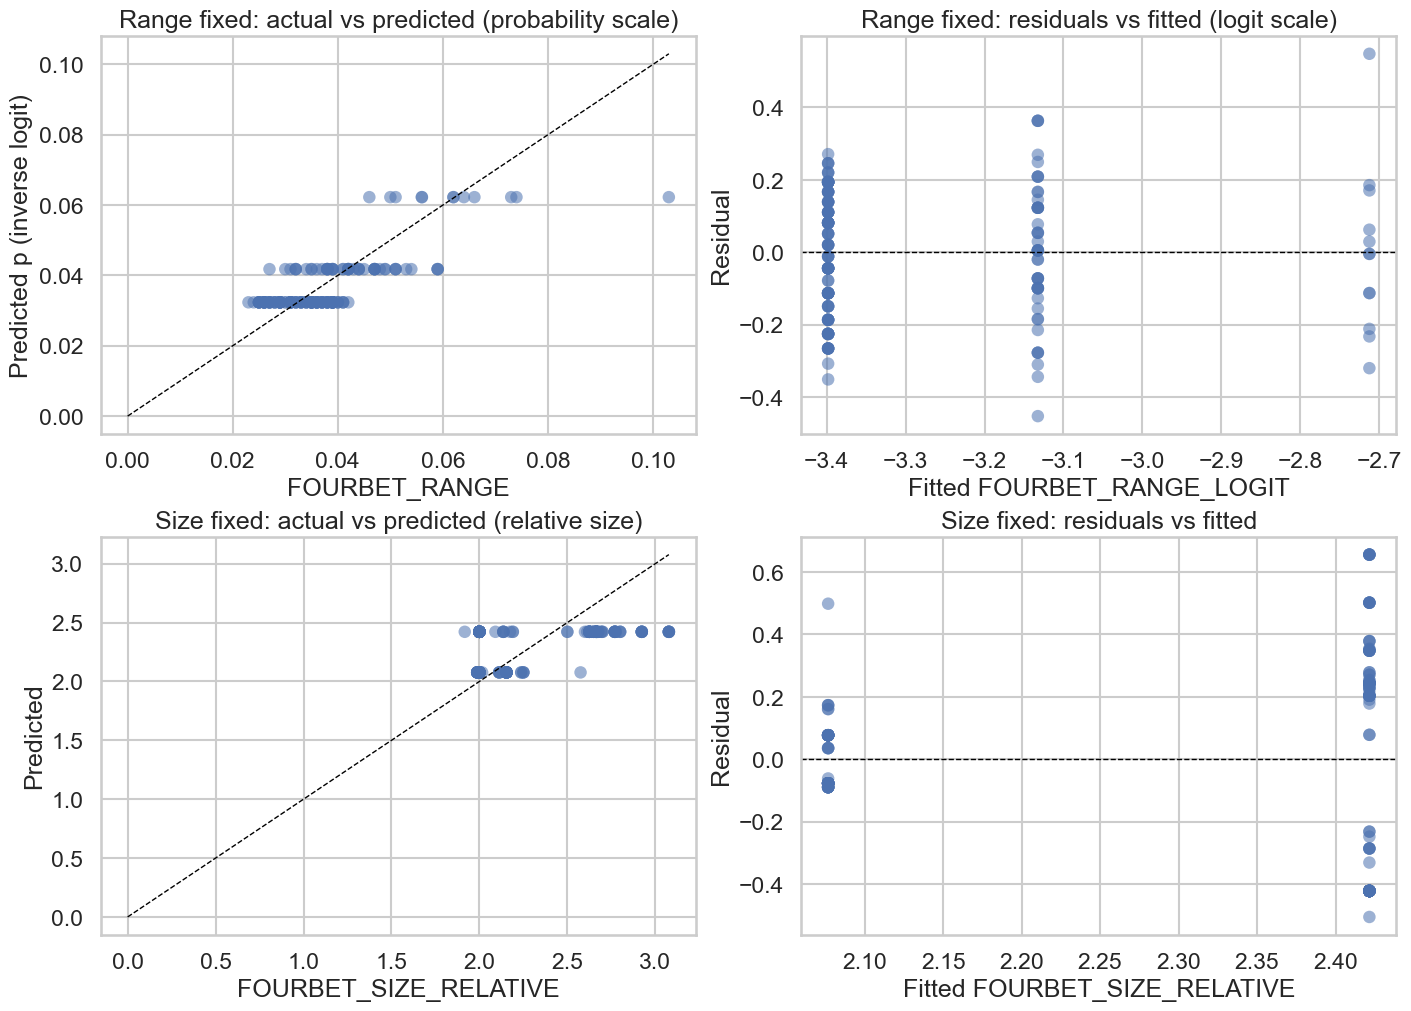

In [17]:
# Actual vs predicted and residuals for the fixed-specification models.
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

hi = max(float(analysis_df["FOURBET_RANGE"].max()), float(range_pred_prob_fixed.max()))
axes[0, 0].scatter(analysis_df["FOURBET_RANGE"], range_pred_prob_fixed, alpha=0.55, edgecolors="none")
axes[0, 0].plot([0, hi], [0, hi], color="black", linestyle="--", linewidth=1)
axes[0, 0].set_title("Range fixed: actual vs predicted (probability scale)")
axes[0, 0].set_xlabel("FOURBET_RANGE")
axes[0, 0].set_ylabel("Predicted p (inverse logit)")

axes[0, 1].scatter(fit_range_fixed.fittedvalues, fit_range_fixed.resid, alpha=0.55, edgecolors="none")
axes[0, 1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0, 1].set_title("Range fixed: residuals vs fitted (logit scale)")
axes[0, 1].set_xlabel("Fitted FOURBET_RANGE_LOGIT")
axes[0, 1].set_ylabel("Residual")

size_pred_fixed = fit_size_fixed.fittedvalues
hs = max(float(analysis_df["FOURBET_SIZE_RELATIVE"].max()), float(size_pred_fixed.max()))
axes[1, 0].scatter(analysis_df["FOURBET_SIZE_RELATIVE"], size_pred_fixed, alpha=0.55, edgecolors="none")
axes[1, 0].plot([0, hs], [0, hs], color="black", linestyle="--", linewidth=1)
axes[1, 0].set_title("Size fixed: actual vs predicted (relative size)")
axes[1, 0].set_xlabel("FOURBET_SIZE_RELATIVE")
axes[1, 0].set_ylabel("Predicted")

axes[1, 1].scatter(size_pred_fixed, fit_size_fixed.resid, alpha=0.55, edgecolors="none")
axes[1, 1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1, 1].set_title("Size fixed: residuals vs fitted")
axes[1, 1].set_xlabel("Fitted FOURBET_SIZE_RELATIVE")
axes[1, 1].set_ylabel("Residual")

plt.show()


In [18]:
analysis_df["range_pred_logit"] = range_result.model.predict(analysis_df)
analysis_df["range_pred"] = 1 / (1 + np.exp(-analysis_df["range_pred_logit"]))
analysis_df["size_pred_relative"] = size_result.model.predict(analysis_df)

analysis_df[[
    "RECORD_NO",
    "FOURBET_RANGE",
    "range_pred",
    "FOURBET_SIZE_RELATIVE",
    "size_pred_relative",
]].head()


,RECORD_NO,FOURBET_RANGE,range_pred,FOURBET_SIZE_RELATIVE,size_pred_relative
0,1,0.029,0.031414,2.153846,2.110317
1,2,0.029,0.029273,2.153846,2.110317
2,3,0.028,0.027274,2.153846,2.110317
3,4,0.027,0.028657,2.153846,2.110317
4,5,0.025,0.027777,3.076923,2.494056


### Per-observation fit and scenario heatmaps

Scatter plots compare each row’s actual outcome to the fitted value (45° line = perfect pointwise fit). Heatmaps show **mean** `FOURBET_RANGE` across opener/3-bettor and 3-bettor/4-bettor grids.


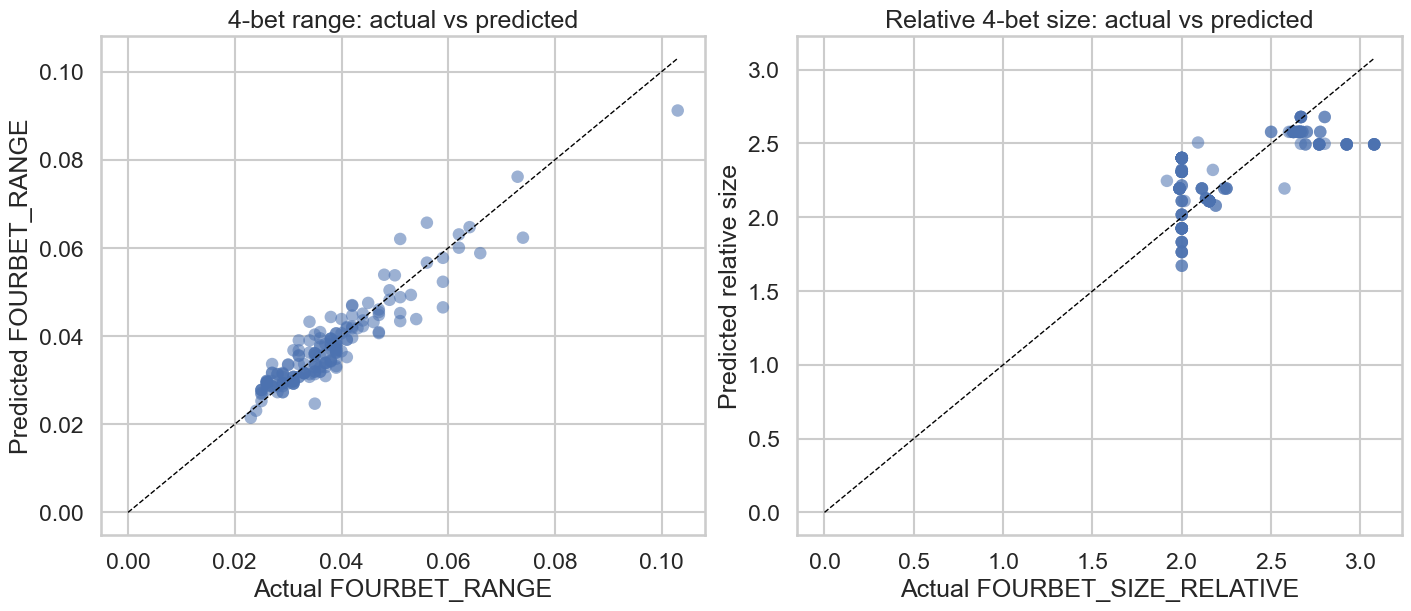

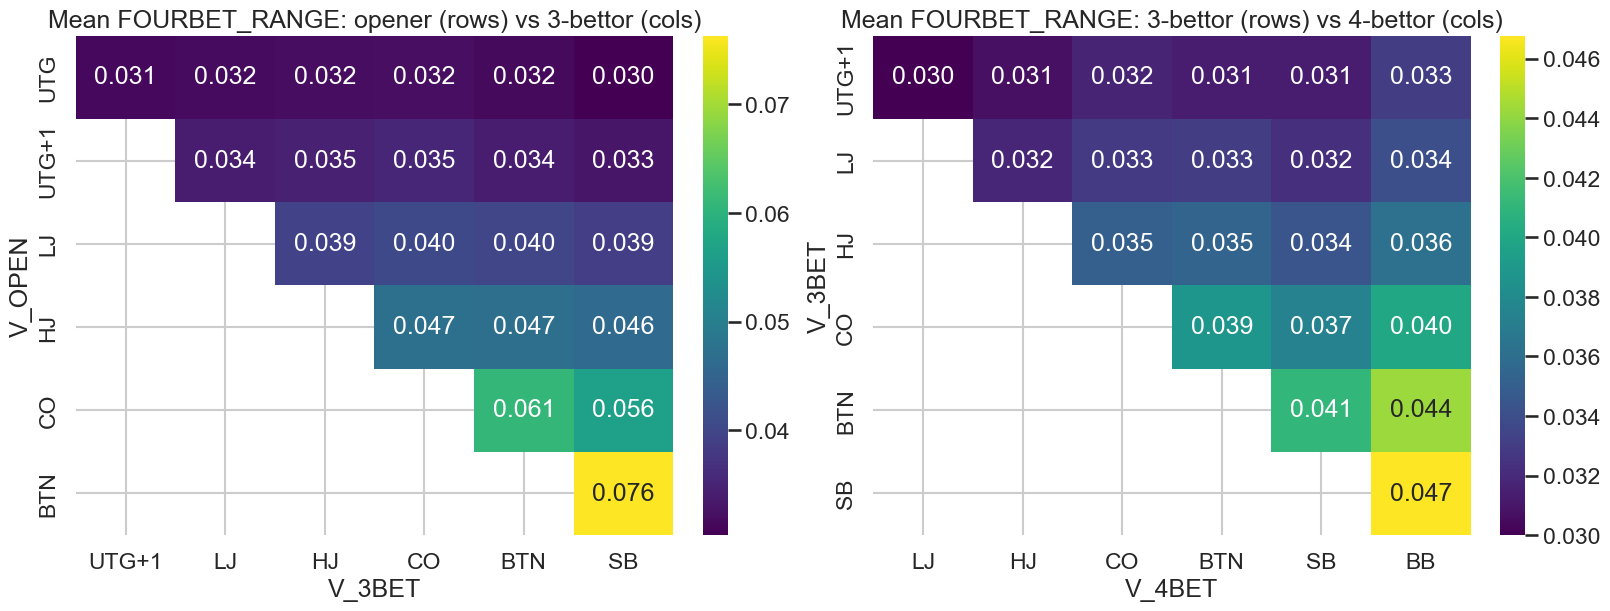

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
hi = max(float(analysis_df["FOURBET_RANGE"].max()), float(analysis_df["range_pred"].max()))
axes[0].scatter(analysis_df["FOURBET_RANGE"], analysis_df["range_pred"], alpha=0.55, edgecolors="none")
axes[0].plot([0, hi], [0, hi], color="black", linestyle="--", linewidth=1)
axes[0].set_title("4-bet range: actual vs predicted")
axes[0].set_xlabel("Actual FOURBET_RANGE")
axes[0].set_ylabel("Predicted FOURBET_RANGE")

hs = max(float(analysis_df["FOURBET_SIZE_RELATIVE"].max()), float(analysis_df["size_pred_relative"].max()))
axes[1].scatter(analysis_df["FOURBET_SIZE_RELATIVE"], analysis_df["size_pred_relative"], alpha=0.55, edgecolors="none")
axes[1].plot([0, hs], [0, hs], color="black", linestyle="--", linewidth=1)
axes[1].set_title("Relative 4-bet size: actual vs predicted")
axes[1].set_xlabel("Actual FOURBET_SIZE_RELATIVE")
axes[1].set_ylabel("Predicted relative size")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
p_open = (
    analysis_df.groupby(["V_OPEN", "V_3BET"], observed=False)["FOURBET_RANGE"].mean().unstack()
)
sns.heatmap(p_open, annot=True, fmt=".3f", cmap="viridis", ax=axes[0])
axes[0].set_title("Mean FOURBET_RANGE: opener (rows) vs 3-bettor (cols)")

p_34 = (
    analysis_df.groupby(["V_3BET", "V_4BET"], observed=False)["FOURBET_RANGE"].mean().unstack()
)
sns.heatmap(p_34, annot=True, fmt=".3f", cmap="viridis", ax=axes[1])
axes[1].set_title("Mean FOURBET_RANGE: 3-bettor (rows) vs 4-bettor (cols)")
plt.show()


## Actual versus expected diagnostics

The plots below compare the mean observed outcome to the mean fitted value across the main visualisation variables:

- `V_GAME`
- `V_OPEN`
- `V_3BET`
- `V_4BET`

If the model captures the broad structural trends well, the two lines should track each other closely by category.


In [20]:
def grouped_actual_vs_expected(
    data: pd.DataFrame,
    group_col: str,
    actual_col: str,
    predicted_col: str,
    title: str,
    ax: plt.Axes,
) -> None:
    """Plot grouped observed vs fitted means for one categorical variable."""
    grouped = (
        data.groupby(group_col, observed=False)
        .agg(actual=(actual_col, "mean"), predicted=(predicted_col, "mean"), n=(actual_col, "size"))
        .reset_index()
    )

    sns.lineplot(data=grouped, x=group_col, y="actual", marker="o", linewidth=2.5, label="Actual", ax=ax)
    sns.lineplot(data=grouped, x=group_col, y="predicted", marker="o", linewidth=2.5, label="Expected", ax=ax)
    ax.set_title(title)
    ax.set_xlabel(group_col)
    ax.set_ylabel(actual_col)
    ax.tick_params(axis="x", rotation=30)


def plot_diagnostics(data: pd.DataFrame, actual_col: str, predicted_col: str, prefix: str) -> None:
    """Create four actual-vs-expected plots across the main visualisation dimensions."""
    fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)
    grouped_actual_vs_expected(data, "V_GAME", actual_col, predicted_col, f"{prefix}: by game", axes[0, 0])
    grouped_actual_vs_expected(data, "V_OPEN", actual_col, predicted_col, f"{prefix}: by opener", axes[0, 1])
    grouped_actual_vs_expected(data, "V_3BET", actual_col, predicted_col, f"{prefix}: by 3-bettor", axes[1, 0])
    grouped_actual_vs_expected(data, "V_4BET", actual_col, predicted_col, f"{prefix}: by 4-bettor", axes[1, 1])
    handles, labels = axes[0, 0].get_legend_handles_labels()
    for ax in axes.ravel():
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=True)
    plt.show()


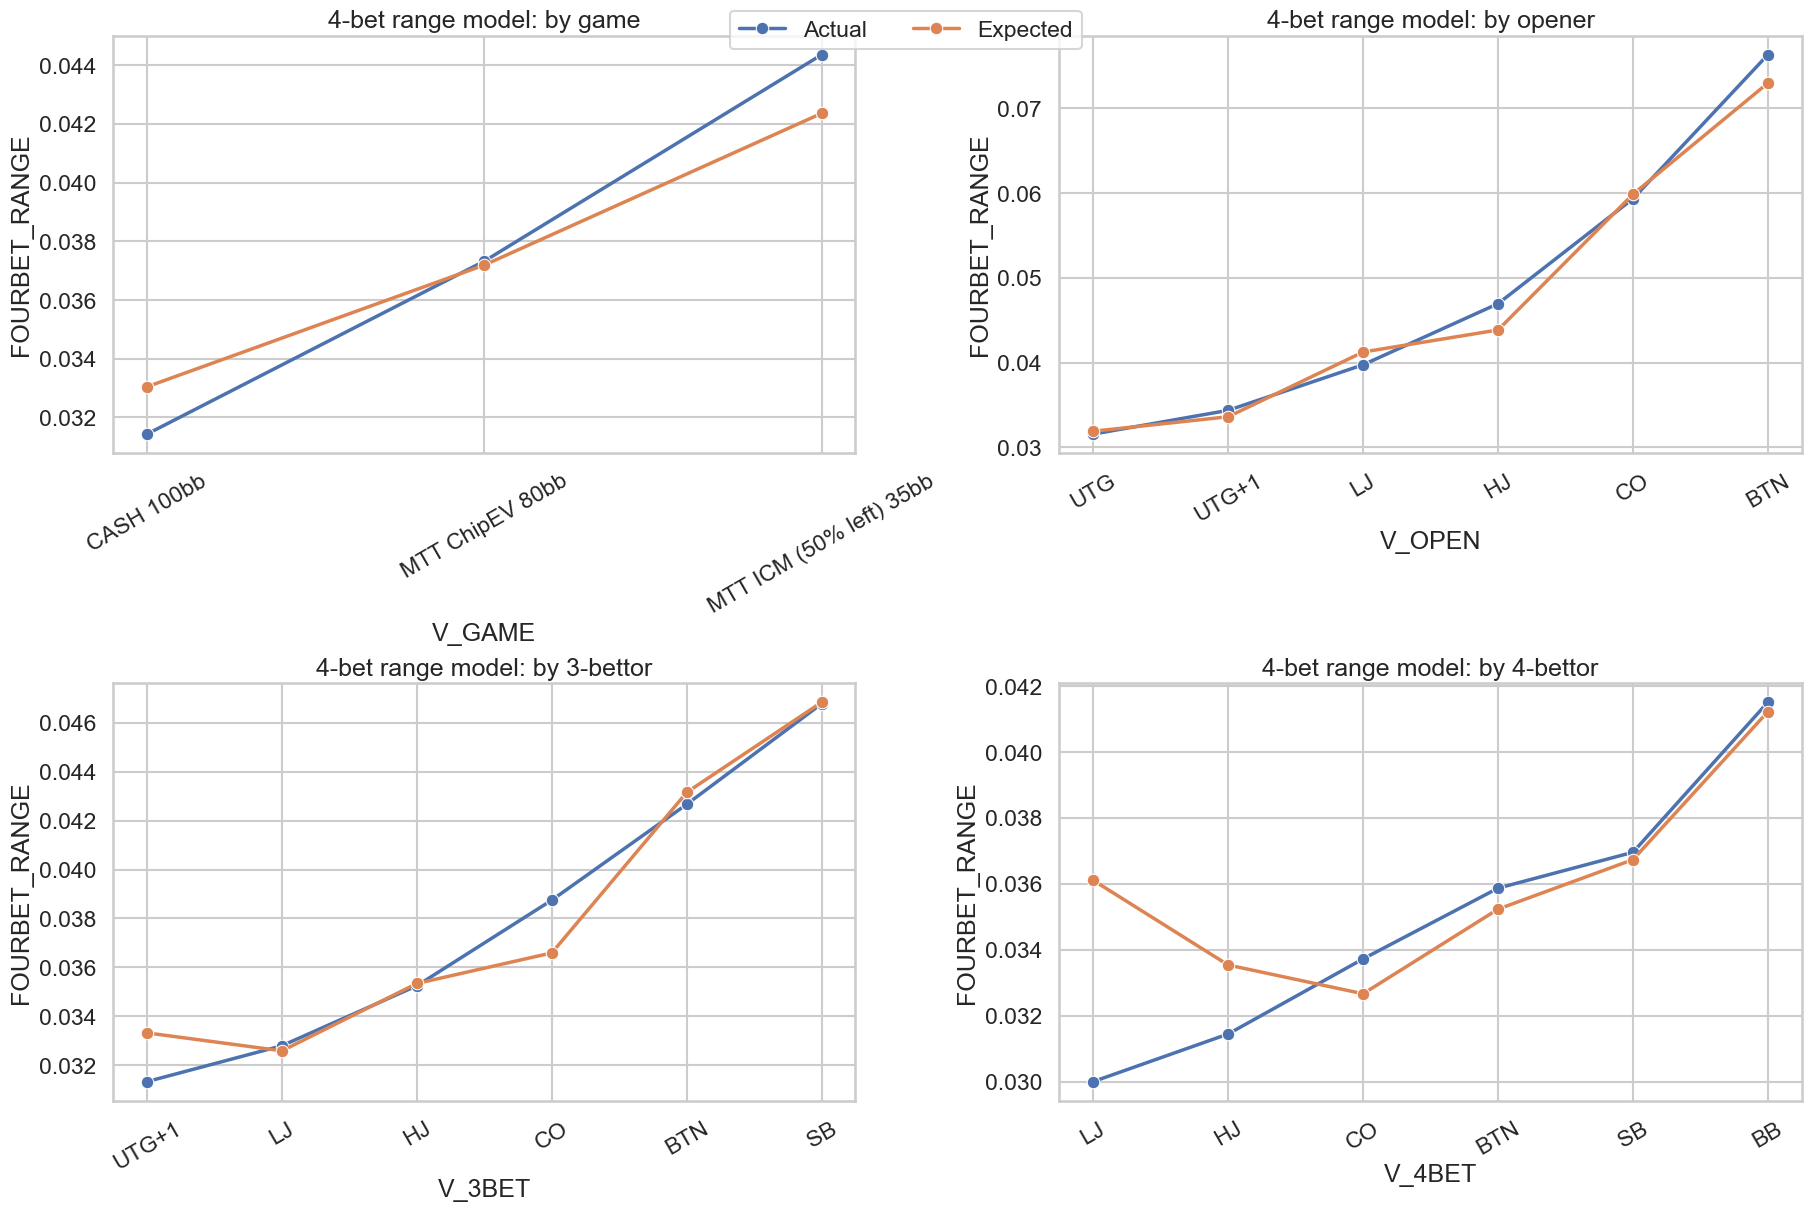

In [21]:
plot_diagnostics(
    data=analysis_df,
    actual_col="FOURBET_RANGE",
    predicted_col="range_pred",
    prefix="4-bet range model",
)


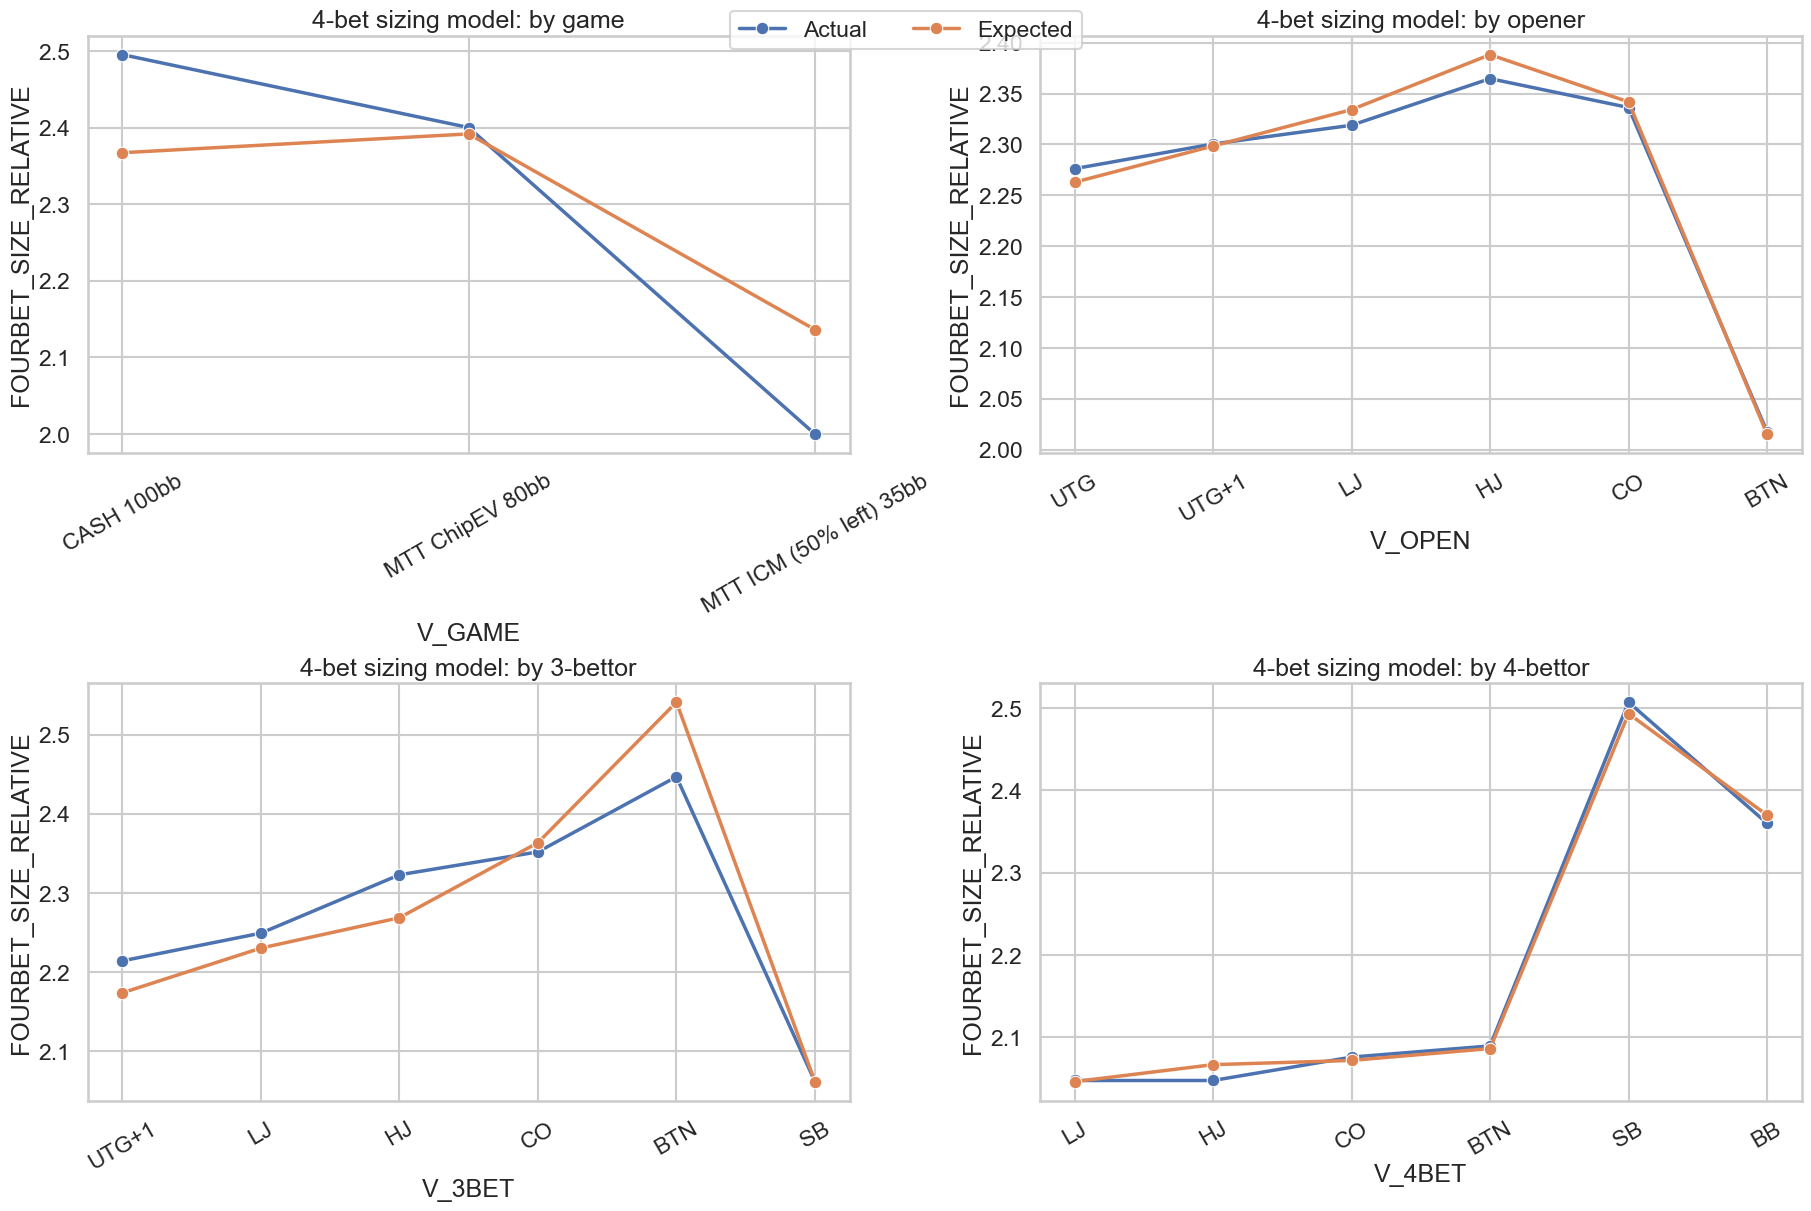

In [22]:
plot_diagnostics(
    data=analysis_df,
    actual_col="FOURBET_SIZE_RELATIVE",
    predicted_col="size_pred_relative",
    prefix="4-bet sizing model",
)


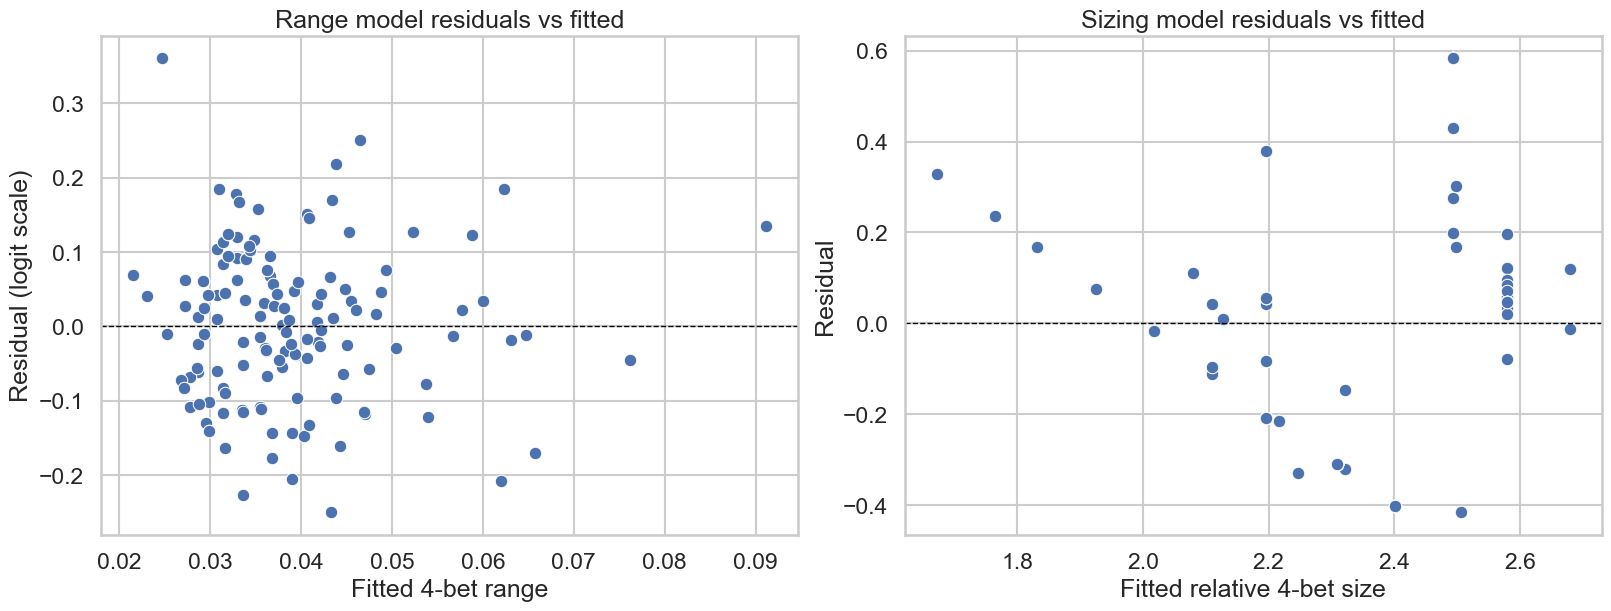

In [23]:
# Optional extra diagnostics: residual plots for both final models.
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

sns.scatterplot(x=analysis_df["range_pred"], y=range_result.model.resid, ax=axes[0])
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Range model residuals vs fitted")
axes[0].set_xlabel("Fitted 4-bet range")
axes[0].set_ylabel("Residual (logit scale)")

sns.scatterplot(x=analysis_df["size_pred_relative"], y=size_result.model.resid, ax=axes[1])
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Sizing model residuals vs fitted")
axes[1].set_xlabel("Fitted relative 4-bet size")
axes[1].set_ylabel("Residual")

plt.show()


## Interpretation notes

The fitted models describe **patterns in your GTO export** on a fixed grid of 168 scenarios; they are not causal statements about live play.

When reviewing results, focus on:

- the **null-model baseline** table (sample mean range vs `sigmoid(intercept)` on the logit scale),
- which terms survive forward BIC (order printed above) and whether that list is plausible for such a small **n**,
- sign and magnitude of selected coefficients,
- whether game type shifts both frequency and sizing,
- whether blind cold 4-bets differ from in-position cold 4-bets,
- whether grouped actual-versus-expected lines stay aligned across opener / 3-bettor / 4-bettor positions.

For stricter or more portable inference, compare this forward-BIC approach with:

1. a manually curated small model,
2. penalized selection (Lasso / elastic net) on the design matrix,
3. cross-validated error (e.g. leave-one-scenario-out or grouped folds by matchup).
